# <center> <font color='blue'> **An Attention-based Conditional Diffusion Model for Super-resolved Stochastic Passive Microwave Satellite Rainfall Retrievals** <center>

#### <center> <font color='balck'> Buddha Subedi, Mahyar Garshasbi, Ardeshir Ebtehaj <center>
#### <center> Saint Anthony Falls Laboratory, Department of Civil Environmental and Geo- Engineering,
#### <center> University of Minnesota <center>
#### <center> Date: December, 2026 (rev 01)


<p align="justify">
This repository introduces <strong>D</strong>iffusion-based PMW <strong>R</strong>ainfall r<strong>E</strong>trievals with <strong>A</strong>ttention <strong>M</strong>echanisms (DREAM), a two-stage probabilistic framework for super-resolved PMW retrieval at near-global scale. First, a residual U-Net (Res-UNet) trained with mean squared error (MSE) and sliced Wasserstein distance loss generates coarse deterministic estimates at Global Precipitation Measurement (GPM) Microwave Imager (GMI) resolution. Second, a conditional denoising diffusion probabilistic model (DDPM) learns the residual toward high-resolution Dual-frequency Precipitation Radar (DPR) targets, fusing multi-frequency brightness temperatures and reanalysis variables through channel, cross-, self-, and bottleneck dual-attention mechanisms. Evaluated on 2023 GPM overpasses, including Hurricane Calvin, DREAM substantially outperforms deterministic baselines in spatial variability, extreme precipitation frequency, and power spectral fidelity.
</p>

This notebook is organized as follows. Section 1, describes the data including the GPM and ERA5 reanalysis data from the European Centre for Medium-Range Weather Forecasts (ECMWF). Section 2 describes the methodolgy for training the networks, and the last section provides an example for precipitation orbital retrieval using the proposed algorithm.

# **1. Data**

**1.1** **Data Description**

<span style="color:green;"><b><i>1.1.1 Radiometric and Reanalysis Conditioning Data</i></b></span>

Brightness temperatures (TBs) from GMI radiometer mapped into native grids of DPR is used in this study as inputs to AE-RCD. Furthermore, a set of hourly [ERA5](https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5) reanalysis products -- available at spatial resolution of 31km is used as ancillary input features to implicitly learn the relationships between land-atmosphere dynamical and thermodynamic state variables and their emissivity.


***GMI TBs***
*   Thirteen frequency channels from 10 to 183 GHz

***Atmospheric Variables***
*   tclw = Total Column Cloud Liquid Water ($\rm kg/m^2$)
*   tciw = Total Column Cloud Ice Water ($\rm kg/m^2$)
*   tcwv = Total Column Water Vapor ($\rm kg/m^2$)
*   cape = Convective Available Potential Energy ($\rm j/kg$)
*   t2m = 2m air temperature ($\rm K$)
*   tcslw = Total Column Supercooled Liquid Water ($\rm \frac{kg}{m^2}$)
*   tcw = Total Column Water ($\rm \frac{kg}{m^3}$)


***Surface Type Variables***
*   lsm = LandSeaMask
*   sd = Snow Depth ($\rm m$)

<span style="color:green;"><b><i>1.1.2 Output Precipitation Rates</i></b></span>

In this study, we use near-surface rainfall rates from the dual-frequency Ku–Ka retrievals in full-scan (FS) mode to train and validate the PMW precipitation retrieval framework, focusing only on the liquid precipitation phase. 

## **1.2 Database Organization and Loading**

**Inputs for the DREAM framework are as follows:**
> <span style="color:green;"><b><i> Inputs of Stage I</i></b></span>

*   $\text{TBs} = X_{train}(:,1:13)$ (Brightness Temperature at 13 GMI channels [K])
*   $ \text{tciw} = X_{train}(:,14)$ (Cloud Liquid Water Path)
*   $\text{tclw} = X_{train}(:,15)$ (Cloud Ice Water Path)
*   $\text{tcwv} = X_{train}(:,16)$ (2-meter Air Temperature)
*   $\text{t2m} = X_{train}(:,17)$ (Water Vapor Path)
*   $\text{cape} = X_{train}(:,18)$ (Convective Potential Energy)


*   $\text{sd} = X_{train}(:,22)$ (Snow Depth)
*   $ \text{tcslw} = X_{train}(:,23)$ (Total Column Supercooled Liquid Water)
*   $\text{tcw} = X_{train}(:,24)$ (Total Column Water)
*   $\text{lsm} = X_{train}(:,26)$ (LandSeaMask)




> <span style="color:green;"><b><i> Output of Stage I</i></b></span>

*   Output of the Res-UNet trained in Stage I is **Smooth DPR rainfall**

**For the Attention enhanced conditonal DDPM in Stage II, the inputs and outputs are as follows:**

> <span style="color:green;"><b><i> Inputs of Stage II</i></b></span>

*    The same set of input features that was used for Stage I is used here as well

> <span style="color:green;"><b><i> Output of Stage II</i></b></span>

*   Output of the Stage II is a vector containing residue of the rainfall rate [$\rm mm.hr^{-1}$]. The residue here is the difference between the smooth rainfall retrievals from Stage I and DPR rainfall.

## **1.3 Code**
To run this notebook on Google Colab, you need to clone this repository

### **1.3.1 Stage I**
This stage involves training a determinisitic Residual U-Net (Res-UNet) with sliced wasserstein distance regularisation.

<span style="color:green;"><b><i> Import Necessary Packages</i></b></span>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import warnings
from matplotlib.colors import LinearSegmentedColormap

<span style="color:green;"><b><i> Input and Output Directories</i></b></span>

In [ ]:
# Input and Output Directory
input_dir = "/scratch.global/subed042/EE_project/grl_dpr_patches_32X32_UNet"


OUTPUT_DIR = "./resunet_swd_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_resunet_model_swd.pth")
HISTORY_PLOT_PATH = os.path.join(OUTPUT_DIR, "resunet_training_history_swd.png")
COMPARISON_DIR = os.path.join(OUTPUT_DIR, "resunet_comparison_plots_swd")
os.makedirs(COMPARISON_DIR, exist_ok=True)

<span style="color:green;"><b><i> Data Processor</i></b></span>

In [ ]:
class DataProcessor:
    def __init__(self, zero_threshold=0.2):
        self.tb_mean = None
        self.tb_std = None
        self.era5_mean = None
        self.era5_std = None
        self.rain_mean = None
        self.rain_std = None
        self.zero_threshold = zero_threshold

    def fit(self, tb_data, era5_data, rain_data):
        self.tb_mean = tb_data.mean(dim=(0, 2, 3), keepdim=True)
        self.tb_std = tb_data.std(dim=(0, 2, 3), keepdim=True)

        self.era5_mean = era5_data.mean(dim=(0, 2, 3), keepdim=True)
        self.era5_std = era5_data.std(dim=(0, 2, 3), keepdim=True)

        rain_positive = rain_data[rain_data > 0]
        if len(rain_positive) > 0:
            rain_log = torch.log1p(rain_positive)
            self.rain_mean = rain_log.mean()
            self.rain_std = rain_log.std()
        else:
            self.rain_mean = torch.tensor(0.0)
            self.rain_std = torch.tensor(1.0)

    def normalize_tb(self, tb_data):
        return (tb_data - self.tb_mean) / (self.tb_std + 1e-8)

    def normalize_era5(self, era5_data):
        return (era5_data - self.era5_mean) / (self.era5_std + 1e-8)

    def normalize_rain(self, rain_data):
        rain_log = torch.log1p(rain_data.clamp(min=0))
        return (rain_log - self.rain_mean) / (self.rain_std + 1e-8)

    def denormalize_rain(self, rain_norm):
        rain_log = rain_norm * self.rain_std + self.rain_mean
        rain_physical = torch.expm1(rain_log)
        rain_physical = torch.clamp(rain_physical, min=0)
        return rain_physical

    def normalized_to_log_space(self, rain_norm):
        return rain_norm * self.rain_std + self.rain_mean

<span style="color:green;"><b><i> Load Training Data</i></b></span>

In [ ]:
def load_train_data_custom(
    patches_dir,
    file_list=None,
    ocean_cap=25000,
    land_cap=25000,
    lsm_idx=25,
    lsm_threshold=0.5
):
    """
    Train loading rule:
    - keep up to ocean_cap samples from ocean patches
    - keep up to land_cap samples from land patches
    - ignore snow depth completely
    """

    if file_list is None:
        all_files = sorted([f for f in os.listdir(patches_dir) if f.endswith(".npy")])
    else:
        all_files = list(file_list)

    np.random.shuffle(all_files)

    print("=" * 90)
    print("TRAIN DATA LOADING WITH LAND/OCEAN BALANCING")
    print("=" * 90)
    print(f"Candidate files : {len(all_files)}")
    print(f"Ocean cap       : {ocean_cap}")
    print(f"Land cap        : {land_cap}")
    print(f"LSM index       : {lsm_idx}")
    print(f"LSM threshold   : {lsm_threshold}")
    print("=" * 90)

    tb_ocean, era5_ocean, rain_ocean = [], [], []
    tb_land, era5_land, rain_land = [], [], []

    scanned_files = 0
    invalid_shape = 0
    nan_skipped = 0
    extreme_rain_skipped = 0
    failed_load = 0

    true_ocean_total = 0
    true_land_total = 0

    pbar = tqdm(all_files, desc="Scanning files", ncols=150)

    for fname in pbar:
        scanned_files += 1

        try:
            patch = np.load(os.path.join(patches_dir, fname))
        except Exception:
            failed_load += 1
            continue

        if patch.shape != (32, 32, 31):
            invalid_shape += 1
            continue

        try:
            tb = patch[:, :, :13]
            era5 = patch[:, :, [13, 14, 15, 16, 17, 21, 22, 23, 25]]
            rain = patch[:, :, -1:]
            lsm = patch[:, :, lsm_idx]
        except Exception:
            failed_load += 1
            continue

        if (
            np.isnan(tb).any()
            or np.isnan(era5).any()
            or np.isnan(rain).any()
            or np.isnan(lsm).any()
        ):
            nan_skipped += 1
            continue

        if rain.max() > 500:
            extreme_rain_skipped += 1
            continue

        mean_lsm = lsm.mean()

        if mean_lsm < lsm_threshold:
            true_ocean_total += 1

            if len(tb_ocean) < ocean_cap:
                tb_ocean.append(tb)
                era5_ocean.append(era5)
                rain_ocean.append(rain)

        else:
            true_land_total += 1

            if len(tb_land) < land_cap:
                tb_land.append(tb)
                era5_land.append(era5)
                rain_land.append(rain)

        pbar.set_postfix({
            "ocean": f"{len(tb_ocean)}/{ocean_cap}",
            "land": f"{len(tb_land)}/{land_cap}"
        })

        if len(tb_ocean) >= ocean_cap and len(tb_land) >= land_cap:
            break
            
    print(
        f"\nLoaded: ocean={len(tb_ocean)}, land={len(tb_land)} | "
        f"scanned={scanned_files} | "
        f"invalid={invalid_shape} | "
        f"nan={nan_skipped} | "
        f"extreme={extreme_rain_skipped} | "
        f"failed={failed_load}"
    )


    tb_list = tb_ocean + tb_land
    era5_list = era5_ocean + era5_land
    rain_list = rain_ocean + rain_land

    total_loaded = len(tb_list)

    print("-" * 90)
    print(f"Total kept for train before shuffle: {total_loaded}")

    if total_loaded == 0:
        raise ValueError("No valid train samples found!")

    combined = list(zip(tb_list, era5_list, rain_list))
    np.random.shuffle(combined)

    tb_list, era5_list, rain_list = zip(*combined)

    tb_array = np.array(tb_list).transpose(0, 3, 1, 2)
    era5_array = np.array(era5_list).transpose(0, 3, 1, 2)
    rain_array = np.array(rain_list).transpose(0, 3, 1, 2)

    tb_tensor = torch.FloatTensor(tb_array)
    era5_tensor = torch.FloatTensor(era5_array)
    rain_tensor = torch.FloatTensor(rain_array)

    print("\nFinal train tensor shapes:")
    print(f"  TB   : {tb_tensor.shape}")
    print(f"  ERA5 : {era5_tensor.shape}")
    print(f"  Rain : {rain_tensor.shape}")

    return tb_tensor, era5_tensor, rain_tensor

<span style="color:green;"><b><i> Residual Block</i></b></span>

In [ ]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualConvBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out

<span style="color:green;"><b><i> Residual U-Net</i></b></span>

In [ ]:
class ResidualUNet(nn.Module):
    def __init__(self, tb_channels=13, era5_channels=9, base_channels=64):
        super(ResidualUNet, self).__init__()

        in_channels = tb_channels + era5_channels

        self.enc1 = ResidualConvBlock(in_channels, base_channels)
        self.enc2 = ResidualConvBlock(base_channels, base_channels * 2)
        self.enc3 = ResidualConvBlock(base_channels * 2, base_channels * 4)
        self.enc4 = ResidualConvBlock(base_channels * 4, base_channels * 8)

        self.bottleneck = ResidualConvBlock(base_channels * 8, base_channels * 16)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = ResidualConvBlock(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = ResidualConvBlock(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ResidualConvBlock(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ResidualConvBlock(base_channels * 2, base_channels)

        self.final_conv = nn.Conv2d(base_channels, 1, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, tb_features, era5_features):
        x = torch.cat([tb_features, era5_features], dim=1)

        enc1 = self.enc1(x)
        p1 = self.pool(enc1)

        enc2 = self.enc2(p1)
        p2 = self.pool(enc2)

        enc3 = self.enc3(p2)
        p3 = self.pool(enc3)

        enc4 = self.enc4(p3)
        p4 = self.pool(enc4)

        bottleneck = self.bottleneck(p4)

        d4 = self.up4(bottleneck)
        d4 = torch.cat([d4, enc4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, enc3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, enc2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, enc1], dim=1)
        d1 = self.dec1(d1)

        output = self.final_conv(d1)
        return output

<span style="color:green;"><b><i> Loss Function</i></b></span>

In [ ]:
class CombinedMSESWDLoss(nn.Module):
    def __init__(self, processor, lambda_swd=0.02, num_projections=16, projection_seed=1234):
        super().__init__()
        self.processor = processor
        self.lambda_swd = lambda_swd
        self.num_projections = num_projections
        self.projection_seed = projection_seed
        self.mse = nn.MSELoss()

    def sliced_wasserstein_distance(self, pred_log, target_log):
        """
        Sliced Wasserstein Distance using 1D Wasserstein-1 distance.

        pred_log, target_log: tensors of shape [B, C, H, W] or [B, H, W]
        """

        B = pred_log.shape[0]

        pred_flat = pred_log.reshape(B, -1)
        target_flat = target_log.reshape(B, -1)

        D = pred_flat.shape[1]
        device = pred_flat.device

        gen = torch.Generator(device=device)
        gen.manual_seed(self.projection_seed + D)

        projections = torch.randn(
            self.num_projections,
            D,
            generator=gen,
            device=device
        )

        projections = projections / (torch.norm(projections, dim=1, keepdim=True) + 1e-8)

        pred_proj = pred_flat @ projections.T
        target_proj = target_flat @ projections.T

        pred_proj_sorted, _ = torch.sort(pred_proj, dim=0)
        target_proj_sorted, _ = torch.sort(target_proj, dim=0)

        # 1D Wasserstein-1 distance
        swd = torch.mean(torch.abs(pred_proj_sorted - target_proj_sorted))

        return swd

    def forward(self, pred_norm, target_norm):
        mse_loss = self.mse(pred_norm, target_norm)

        pred_log = self.processor.normalized_to_log_space(pred_norm)
        target_log = self.processor.normalized_to_log_space(target_norm)

        swd_loss = self.sliced_wasserstein_distance(pred_log, target_log)

        total_loss = (1-self.lambda_swd)*mse_loss + self.lambda_swd * swd_loss

        return total_loss, mse_loss.detach(), swd_loss.detach()

<span style="color:green;"><b><i> Training Function</i></b></span>

In [ ]:
def train_resunet_model(
    train_data,
    val_data,
    num_epochs=100,
    batch_size=32,
    learning_rate=1e-4,
    lambda_swd=0.05,
    num_projections=16
):
    (tb_train, era5_train, rain_train) = train_data
    (tb_val, era5_val, rain_val) = val_data

    processor = DataProcessor(zero_threshold=0.1)
    processor.fit(tb_train, era5_train, rain_train)

    tb_train_norm = processor.normalize_tb(tb_train)
    era5_train_norm = processor.normalize_era5(era5_train)
    rain_train_norm = processor.normalize_rain(rain_train)

    tb_val_norm = processor.normalize_tb(tb_val)
    era5_val_norm = processor.normalize_era5(era5_val)
    rain_val_norm = processor.normalize_rain(rain_val)

    train_dataset = TensorDataset(tb_train_norm, era5_train_norm, rain_train_norm)
    val_dataset = TensorDataset(tb_val_norm, era5_val_norm, rain_val_norm)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ResidualUNet().to(device)

    criterion = CombinedMSESWDLoss(
        processor=processor,
        lambda_swd=lambda_swd,
        num_projections=num_projections,
        projection_seed=1234
    )

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_mse': [], 'val_mse': [],
        'train_swd': [], 'val_swd': []
    }

    best_val_loss = float('inf')

    print(f"Training Residual U-Net model on {device}")
    print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
    print(f"Loss = MSE + {lambda_swd} * SWD")
    print("=" * 70)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_mse_total = 0.0
        train_swd_total = 0.0

        for tb_batch, era5_batch, rain_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            tb_batch = tb_batch.to(device)
            era5_batch = era5_batch.to(device)
            rain_batch = rain_batch.to(device)

            optimizer.zero_grad()
            predictions = model(tb_batch, era5_batch)
            loss, mse_part, swd_part = criterion(predictions, rain_batch)

            loss.backward()
            optimizer.step()

            bs = tb_batch.size(0)
            train_loss += loss.item() * bs
            train_mse_total += mse_part.item() * bs
            train_swd_total += swd_part.item() * bs

        model.eval()
        val_loss = 0.0
        val_mse_total = 0.0
        val_swd_total = 0.0

        with torch.no_grad():
            for tb_batch, era5_batch, rain_batch in val_loader:
                tb_batch = tb_batch.to(device)
                era5_batch = era5_batch.to(device)
                rain_batch = rain_batch.to(device)

                predictions = model(tb_batch, era5_batch)
                loss, mse_part, swd_part = criterion(predictions, rain_batch)

                bs = tb_batch.size(0)
                val_loss += loss.item() * bs
                val_mse_total += mse_part.item() * bs
                val_swd_total += swd_part.item() * bs

        train_loss_avg = train_loss / len(train_dataset)
        val_loss_avg = val_loss / len(val_dataset)
        train_mse_avg = train_mse_total / len(train_dataset)
        val_mse_avg = val_mse_total / len(val_dataset)
        train_swd_avg = train_swd_total / len(train_dataset)
        val_swd_avg = val_swd_total / len(val_dataset)

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_mse'].append(train_mse_avg)
        history['val_mse'].append(val_mse_avg)
        history['train_swd'].append(train_swd_avg)
        history['val_swd'].append(val_swd_avg)

        scheduler.step(val_loss_avg)

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss_avg,
                'val_loss': val_loss_avg,
                'lambda_swd': lambda_swd,
                'num_projections': num_projections,
                'tb_mean': processor.tb_mean.cpu(),
                'tb_std': processor.tb_std.cpu(),
                'era5_mean': processor.era5_mean.cpu(),
                'era5_std': processor.era5_std.cpu(),
                'rain_mean': processor.rain_mean.cpu() if torch.is_tensor(processor.rain_mean) else torch.tensor(processor.rain_mean),
                'rain_std': processor.rain_std.cpu() if torch.is_tensor(processor.rain_std) else torch.tensor(processor.rain_std),
                'zero_threshold': processor.zero_threshold
            }

            torch.save(checkpoint, BEST_MODEL_PATH)
            print(f"  ✓ Saved best model to {BEST_MODEL_PATH} (val_loss: {val_loss_avg:.6f})")

        print(
            f"Epoch {epoch+1:3d}/{num_epochs} | "
            f"Train Loss: {train_loss_avg:.6f} | Val Loss: {val_loss_avg:.6f} | "
            f"Train MSE: {train_mse_avg:.6f} | Val MSE: {val_mse_avg:.6f} | "
            f"Train SWD: {train_swd_avg:.6f} | Val SWD: {val_swd_avg:.6f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

    print("=" * 70)
    print(f"Training completed! Best validation loss: {best_val_loss:.6f}")

    return model, processor, history

<span style="color:green;"><b><i> Model Evaluation</i></b></span>

In [ ]:
colors_rain = ['gainsboro', 'seagreen', 'green', 'yellow', 'darkorange', 'red']
cmap_rate_rain = LinearSegmentedColormap.from_list("mycmap_rain", colors_rain)

def evaluate_resunet_model(model, processor, test_data, num_samples=150):
    tb_test, era5_test, rain_test = test_data

    print(f"Test data shapes:")
    print(f"  TB test: {tb_test.shape}")
    print(f"  ERA5 test: {era5_test.shape}")
    print(f"  Rain test: {rain_test.shape}")

    actual_samples = min(num_samples, rain_test.shape[0])
    if actual_samples < num_samples:
        print(
            f"Warning: Only {actual_samples} samples available, "
            f"using {actual_samples} instead of {num_samples}"
        )
        num_samples = actual_samples

    if num_samples == 0:
        print("Error: No test samples available!")
        return []

    tb_test_norm = processor.normalize_tb(tb_test)
    era5_test_norm = processor.normalize_era5(era5_test)

    device = next(model.parameters()).device
    tb_test_norm = tb_test_norm.to(device)
    era5_test_norm = era5_test_norm.to(device)

    model.eval()
    with torch.no_grad():
        predictions_norm = model(
            tb_test_norm[:num_samples],
            era5_test_norm[:num_samples]
        )
        predictions = processor.denormalize_rain(predictions_norm)

    predictions = predictions.cpu()
    rain_true = rain_test[:num_samples]

    rain_cmap = cmap_rate_rain
    diff_cmap = plt.cm.RdBu_r

    all_metrics = []

    for i in range(num_samples):
        true_rain = rain_true[i].cpu().numpy() if hasattr(rain_true[i], "cpu") else rain_true[i].numpy()
        pred_rain = predictions[i].cpu().numpy() if hasattr(predictions[i], "cpu") else predictions[i].numpy()

        true_rain_2d = true_rain[0] if true_rain.ndim == 3 else true_rain
        pred_rain_2d = pred_rain[0] if pred_rain.ndim == 3 else pred_rain

        diff = pred_rain_2d - true_rain_2d

        mae = np.mean(np.abs(diff))
        rmse = np.sqrt(np.mean(diff ** 2))
        bias = np.mean(diff)

        flat_true = true_rain_2d.flatten()
        flat_pred = pred_rain_2d.flatten()

        if np.std(flat_true) > 0 and np.std(flat_pred) > 0:
            correlation = np.corrcoef(flat_true, flat_pred)[0, 1]
        else:
            correlation = 0.0

        zero_threshold = processor.zero_threshold

        zero_fraction_true = (true_rain_2d < zero_threshold).mean()
        zero_fraction_pred = (pred_rain_2d < zero_threshold).mean()

        true_rain_mask = true_rain_2d >= zero_threshold
        pred_rain_mask = pred_rain_2d >= zero_threshold

        if true_rain_mask.any():
            pod = np.sum(true_rain_mask & pred_rain_mask) / np.sum(true_rain_mask)
        else:
            pod = np.nan

        if pred_rain_mask.any():
            far = np.sum(pred_rain_mask & ~true_rain_mask) / np.sum(pred_rain_mask)
        else:
            far = np.nan

        metrics = {
            "true_sample": true_rain_2d,
            "pred_sample": pred_rain_2d,
            "mae": mae,
            "rmse": rmse,
            "bias": bias,
            "correlation": correlation,
            "zero_fraction_true": zero_fraction_true,
            "zero_fraction_pred": zero_fraction_pred,
            "pod": pod,
            "far": far,
            "sample_idx": i
        }

        all_metrics.append(metrics)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        vmax_rain = 4.0

        im1 = axes[0].imshow(
            true_rain_2d,
            cmap=rain_cmap,
            vmin=0,
            vmax=vmax_rain
        )
        axes[0].set_title("True Rainfall", fontsize=12, fontweight="bold")
        axes[0].set_xticks([])
        axes[0].set_yticks([])
        plt.colorbar(
            im1,
            ax=axes[0],
            fraction=0.046,
            pad=0.04,
            label="Rain Rate (mm/hr)"
        )

        im2 = axes[1].imshow(
            pred_rain_2d,
            cmap=rain_cmap,
            vmin=0,
            vmax=vmax_rain
        )
        axes[1].set_title("Residual U-Net + SWD", fontsize=12, fontweight="bold")
        axes[1].set_xlabel(
            f"MAE: {mae:.3f}, RMSE: {rmse:.3f}\nBias: {bias:.3f}",
            fontsize=10,
            fontweight="bold"
        )
        axes[1].set_xticks([])
        axes[1].set_yticks([])
        plt.colorbar(
            im2,
            ax=axes[1],
            fraction=0.046,
            pad=0.04,
            label="Rain Rate (mm/hr)"
        )

        max_abs_diff = max(np.abs(diff).max(), 0.5)
        max_abs_diff = min(max_abs_diff, 2.0)

        im3 = axes[2].imshow(
            diff,
            cmap=diff_cmap,
            vmin=-max_abs_diff,
            vmax=max_abs_diff
        )
        axes[2].set_title("Difference (Pred - True)", fontsize=12, fontweight="bold")
        axes[2].set_xlabel(
            f"Correlation: {correlation:.3f}",
            fontsize=10,
            fontweight="bold"
        )
        axes[2].set_xticks([])
        axes[2].set_yticks([])
        plt.colorbar(
            im3,
            ax=axes[2],
            fraction=0.046,
            pad=0.04,
            label="Difference (mm/hr)"
        )

        plt.suptitle(
            f"Sample {i + 1} - Residual U-Net + SWD",
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

        plt.tight_layout()
        plt.show()

    return all_metrics

<span style="color:green;"><b><i> Main Function</i></b></span>

In [ ]:
def main():
    NUM_EPOCHS = 15
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-4
    LAMBDA_SWD = 0.55
    NUM_PROJECTIONS = 16
    SEED = 42

    input_dir = "/scratch.global/subed042/EE_project/grl_dpr_patches_32X32_UNet"

    LSM_IDX = 25
    LSM_THRESHOLD = 0.5

    OCEAN_CAP_TRAIN = 25000
    LAND_CAP_TRAIN = 25000

    TRAIN_FILE_COUNT = 169500
    VAL_FILE_COUNT = 5000
    TEST_FILE_COUNT = 5000

    print("=" * 90)
    print("RESIDUAL U-NET + SLICED WASSERSTEIN DISTANCE")
    print("=" * 90)

    all_files = sorted([
        f for f in os.listdir(input_dir)
        if f.endswith(".npy")
    ])

    print(f"Total files available: {len(all_files)}")

    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(all_files))
    all_files = [all_files[i] for i in shuffled_idx]

    total_needed = TRAIN_FILE_COUNT + VAL_FILE_COUNT + TEST_FILE_COUNT

    if len(all_files) < total_needed:
        print(
            f"Warning: requested {total_needed} files, "
            f"but only {len(all_files)} are available."
        )
        total_needed = len(all_files)

    selected_files = all_files[:total_needed]

    train_files = selected_files[:TRAIN_FILE_COUNT]

    val_files = selected_files[
        TRAIN_FILE_COUNT:
        TRAIN_FILE_COUNT + VAL_FILE_COUNT
    ]

    test_files = selected_files[
        TRAIN_FILE_COUNT + VAL_FILE_COUNT:
        TRAIN_FILE_COUNT + VAL_FILE_COUNT + TEST_FILE_COUNT
    ]

    print("\nSplit file counts:")
    print(f"  Train candidates : {len(train_files)}")
    print(f"  Val files        : {len(val_files)}")
    print(f"  Test files       : {len(test_files)}")

    print("\nLoading train data with land/ocean balancing...")

    tb_train, era5_train, rain_train = load_train_data_custom(
        patches_dir=input_dir,
        file_list=train_files,
        ocean_cap=OCEAN_CAP_TRAIN,
        land_cap=LAND_CAP_TRAIN,
        lsm_idx=LSM_IDX,
        lsm_threshold=LSM_THRESHOLD
    )

    print("\nLoading validation data without filtering...")
    
    tb_val, era5_val, rain_val = load_train_data_custom(
        patches_dir=input_dir,
        file_list=val_files,
        ocean_cap=500,
        land_cap=500,
        lsm_idx=LSM_IDX,
        lsm_threshold=LSM_THRESHOLD
    )


    print("\nLoading test data without filtering...")
    
    tb_test, era5_test, rain_test = load_train_data_custom(
        patches_dir=input_dir,
        file_list=test_files,
        ocean_cap=500,
        land_cap=500,
        lsm_idx=LSM_IDX,
        lsm_threshold=LSM_THRESHOLD
    )



    train_data = (tb_train, era5_train, rain_train)
    val_data = (tb_val, era5_val, rain_val)
    test_data = (tb_test, era5_test, rain_test)

    print("\nFinal loaded split sizes:")
    print(f"  Train: {train_data[0].shape[0]}")
    print(f"  Val:   {val_data[0].shape[0]}")
    print(f"  Test:  {test_data[0].shape[0]}")

    print("\n" + "=" * 70)
    print("TRAINING PHASE")
    print("=" * 70)

    model, processor, history = train_resunet_model(
        train_data=train_data,
        val_data=val_data,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        lambda_swd=LAMBDA_SWD,
        num_projections=NUM_PROJECTIONS
    )

    print("\n" + "=" * 70)
    print("EVALUATION PHASE")
    print("=" * 70)

    all_metrics = evaluate_resunet_model(
        model,
        processor,
        test_data,
        num_samples=test_data[0].shape[0]
    )

    print("\n" + "=" * 90)
    print("PROGRAM COMPLETED SUCCESSFULLY!")
    print("=" * 90)

    print("\nOutputs generated:")
    print(f"  1. {BEST_MODEL_PATH}")
    print(f"  2. {HISTORY_PLOT_PATH}")
    print(f"  3. {COMPARISON_DIR}/")

    return model, processor, all_metrics


if __name__ == "__main__":
    model, processor, all_metrics = main()

### **1.3.2 Stage II**
This stage involves training an attention enhanced denoising diffusion probabilistic model

<span style="color:green;"><b><i> Import Necessary Packages</i></b></span>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

<span style="color:green;"><b><i> DDPM Data Processor</i></b></span>

In [2]:
class ddpmDataProcessor:
    """Simple data processor for signed residue training."""
    def __init__(self, zero_threshold=0.2, upper_limit_multiplier=20.0, norm_clip_range=(-100, 100)):
        self.tb_scalers = [StandardScaler() for _ in range(13)]
        self.era5_scalers = [StandardScaler() for _ in range(9)]
        self.rain_stats = {}
        self.zero_threshold = zero_threshold
        self.upper_limit_multiplier = upper_limit_multiplier
        self.norm_clip_min, self.norm_clip_max = norm_clip_range

    def fit(self, tb_data, era5_data, rain_data):
        """Fit scalers on training data. Here rain_data is the signed residue target."""
        print("Fitting scalers...")

        for i in range(13):
            tb_channel = tb_data[..., i].flatten()
            tb_channel = tb_channel[~np.isnan(tb_channel)]
            p1, p99 = np.percentile(tb_channel, [1, 99])
            tb_channel = np.clip(tb_channel, p1, p99)
            self.tb_scalers[i].fit(tb_channel.reshape(-1, 1))

        for i in range(9):
            era5_channel = era5_data[..., i].flatten()
            era5_channel = era5_channel[~np.isnan(era5_channel)]
            p1, p99 = np.percentile(era5_channel, [1, 99])
            era5_channel = np.clip(era5_channel, p1, p99)
            self.era5_scalers[i].fit(era5_channel.reshape(-1, 1))

        # Signed residue statistics (NO log1p, NO zero-threshold clipping)
        rain_flat = rain_data.flatten()
        rain_flat = rain_flat[~np.isnan(rain_flat)]
        rain_flat = np.nan_to_num(rain_flat, nan=0.0, posinf=0.0, neginf=0.0)

        mean_val = np.mean(rain_flat)
        std_val = max(np.std(rain_flat), 1e-6)
        p1 = np.percentile(rain_flat, 1) if len(rain_flat) > 0 else 0
        p99 = np.percentile(rain_flat, 99) if len(rain_flat) > 0 else 0

        self.rain_stats = {
            'mean': mean_val,
            'std': std_val,
            'min': rain_flat.min() if len(rain_flat) > 0 else 0,
            'max': rain_flat.max() if len(rain_flat) > 0 else 0,
            'p1': p1,
            'p99': p99,
        }

        print(f"Signed Residue Statistics:")
        print(f"  Mean: {self.rain_stats['mean']:.4f}")
        print(f"  Std : {self.rain_stats['std']:.4f}")
        print(f"  Min : {self.rain_stats['min']:.4f}")
        print(f"  Max : {self.rain_stats['max']:.4f}")
        print(f"  p1  : {self.rain_stats['p1']:.4f}")
        print(f"  p99 : {self.rain_stats['p99']:.4f}")
        print(f"  IMPORTANT: No 0.2-threshold clipping is applied for residue")

        return None, None

    def transform_tb(self, tb_data):
        """Transform TB features"""
        transformed = np.zeros_like(tb_data)
        for i in range(13):
            channel_data = tb_data[..., i]
            original_shape = channel_data.shape
            channel_flat = channel_data.reshape(-1, 1)
            channel_transformed = self.tb_scalers[i].transform(channel_flat)
            transformed[..., i] = channel_transformed.reshape(original_shape)
        return transformed

    def transform_era5(self, era5_data):
        """Transform ERA5 features"""
        transformed = np.zeros_like(era5_data)
        for i in range(9):
            channel_data = era5_data[..., i]
            original_shape = channel_data.shape
            channel_flat = channel_data.reshape(-1, 1)
            channel_transformed = self.era5_scalers[i].transform(channel_flat)
            transformed[..., i] = channel_transformed.reshape(original_shape)
        return transformed

    def transform_rain_to_normalized(self, rain_data, device='cpu', clip=True):
        """No normalization for residue; return residue as-is."""
        if torch.is_tensor(rain_data):
            return rain_data.to(device)
        return torch.FloatTensor(rain_data).to(device)

    def transform_rain_to_physical(self, rain_normalized, apply_threshold=True, apply_clipping=True):
        """No inverse transform for residue; return residue as-is."""
        if torch.is_tensor(rain_normalized):
            return rain_normalized
        return torch.FloatTensor(rain_normalized)

    def apply_zero_threshold(self, rain_physical):
        """No-op for residue."""
        return rain_physical

<span style="color:green;"><b><i> Time Embedding</i></b></span>

In [3]:
def timestep_embedding(timesteps, dim, max_period=10000, device=None):
    """Create sinusoidal timestep embeddings"""
    if device is None:
        device = timesteps.device
    
    half = dim // 2
    max_period_tensor = torch.tensor(max_period, dtype=torch.float32, device=device)
    
    freqs = torch.exp(
        -torch.log(max_period_tensor) * 
        torch.arange(half, dtype=torch.float32, device=device) / half
    )
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

<span style="color:green;"><b><i> TBs Encoder</i></b></span>

In [4]:
class TBEncoder(nn.Module):
    """TB Encoder: Extracts multi-scale TB features with proper spatial alignment"""
    def __init__(self):
        super().__init__()
        
        # Encoder layers for TB features with proper spatial dimensions
        # Level 1: 32x32 → 16x16
        self.conv1 = nn.Sequential(
            nn.Conv2d(13, 64, 3, stride=2, padding=1),  # 32→16
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )
        
        # Level 2: 16x16 → 8x8
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 16→8
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU()
        )
        
        # Level 3: 8x8 → 4x4
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # 8→4
            nn.GroupNorm(8, 256),
            nn.SiLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.GroupNorm(8, 256),
            nn.SiLU()
        )
        
        # Level 4: 4x4 → 2x2
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, stride=2, padding=1),  # 4→2
            nn.GroupNorm(8, 512),
            nn.SiLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.GroupNorm(8, 512),
            nn.SiLU()
        )
        
    def forward(self, tb):
        # Extract multi-scale TB features with proper spatial dimensions
        tb1 = self.conv1(tb)  # [N, 64, 16, 16] - matches after first downsampling ## N is the batch size
        
        tb2 = self.conv2(tb1)  # [N, 128, 8, 8] - matches after second downsampling
        
        tb3 = self.conv3(tb2)  # [N, 256, 4, 4] - matches after third downsampling
        
        tb4 = self.conv4(tb3)  # [N, 512, 2, 2] - matches after fourth downsampling
        
        return tb1, tb2, tb3, tb4

<span style="color:green;"><b><i> ERA5 Encoder</i></b></span>

In [5]:
class ERA5Processor(nn.Module):
    """ERA5 Processor: Converts ERA5 fields into compact latent representation"""
    def __init__(self):
        super().__init__()
        
        self.processor = nn.Sequential(
            # Initial processing (keep at 32x32)
            nn.Conv2d(9, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            
            # Downsample to 16x16
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            
            # Downsample to 8x8
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.GroupNorm(8, 256),
            nn.SiLU(),
            
            # Downsample to 4x4
            nn.Conv2d(256, 512, 3, stride=2, padding=1),
            nn.GroupNorm(8, 512),
            nn.SiLU(),
            
            # Downsample to 2x2
            nn.Conv2d(512, 512, 3, stride=2, padding=1),
            nn.GroupNorm(8, 512),
            nn.SiLU()
        )
        
    def forward(self, era5):
        # Process ERA5 fields to match bottleneck dimensions
        era5_latent = self.processor(era5)  # [N, 512, 2, 2]
        return era5_latent

<span style="color:green;"><b><i> Cross-Attention Block</i></b></span>

In [6]:
class CrossAttentionBlock(nn.Module):
    def __init__(self, query_dim, key_dim, hidden_dim=None, num_heads=8, dropout=0.1):
        super().__init__()
        
        if hidden_dim is None:
            hidden_dim = 4 * query_dim
        
        assert query_dim % num_heads == 0, "query_dim must be divisible by num_heads"
        
        self.norm_query = nn.LayerNorm(query_dim)
        self.norm_keyvalue = nn.LayerNorm(key_dim)
        
        # Always project for consistency (or make it configurable)
        self.key_proj = nn.Linear(key_dim, query_dim)
        self.value_proj = nn.Linear(key_dim, query_dim)
        
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=query_dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.attn_dropout = nn.Dropout(dropout)  # Optional extra dropout
        
        self.ffn_norm = nn.LayerNorm(query_dim)
        self.ffn = nn.Sequential(
            nn.Linear(query_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, query_dim),
            nn.Dropout(dropout)
        )

    def forward(self, query, key_value):
        B, C, H, W = query.shape
        Bk, Ck, Hk, Wk = key_value.shape
        assert B == Bk, "Batch size mismatch"
        
        # Flatten spatial dimensions
        query_flat = query.flatten(2).transpose(1, 2)      # [B, HW, C]
        kv_flat = key_value.flatten(2).transpose(1, 2)     # [B, HkWk, Ck]
        
        # Pre-norm
        query_norm = self.norm_query(query_flat)
        kv_norm = self.norm_keyvalue(kv_flat)
        
        # Project key/value
        key = self.key_proj(kv_norm)
        value = self.value_proj(kv_norm)
        
        # Cross attention
        attn_out, _ = self.cross_attn(query=query_norm, key=key, value=value)
        query_flat = query_flat + self.attn_dropout(attn_out)
        
        # FFN with pre-norm
        query_flat = query_flat + self.ffn(self.ffn_norm(query_flat))
        
        # Reshape back
        output = query_flat.transpose(1, 2).reshape(B, C, H, W)
        return output

<span style="color:green;"><b><i> Channel Attention Block</i></b></span>

In [7]:
class ChannelAttention(nn.Module):
    """Channel attention matching:
       AvgPool/MaxPool -> Conv -> ReLU -> Conv -> Add -> Sigmoid -> Multiply
    """
    def __init__(self, channels, reduction_ratio=16):
        super().__init__()

        reduced_channels = max(1, channels // reduction_ratio)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Shared MLP implemented with 1x1 convolutions
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, reduced_channels, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, channels, kernel_size=1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Two channel descriptors
        avg_out = self.shared_mlp(self.avg_pool(x))   # (B, C, 1, 1)
        max_out = self.shared_mlp(self.max_pool(x))   # (B, C, 1, 1)

        # Add, then sigmoid
        attention = self.sigmoid(avg_out + max_out)   # (B, C, 1, 1)

        # Multiply with input feature map
        out = x * attention

        return out

<span style="color:green;"><b><i> Spatial Attention Block</i></b></span>

In [8]:
class SpatialAttention(nn.Module):
    """Spatial attention module"""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Channel pooling
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        # Concatenate and convolve
        combined = torch.cat([avg_out, max_out], dim=1)
        attention = self.conv(combined)
        
        return self.sigmoid(attention)
    

<span style="color:green;"><b><i> Multi-Stage Conditional Block</i></b></span>

In [9]:
class MultiStageConditionalBlock(nn.Module):
    """Residual block with stage-aware attention.

    Uses channel attention when self-attention is not used (stage_level < 3),
    and self-attention at deeper stages (stage_level >= 3).
    """
    def __init__(self, in_channels, out_channels, time_channels,
                 tb_channels=None, stage_level=1, num_heads=4):
        super().__init__()

        self.stage_level = stage_level

        norm_groups1 = min(8, in_channels)
        norm_groups2 = min(8, out_channels)

        self.conv1 = nn.Sequential(
            nn.GroupNorm(norm_groups1, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )

        self.time_embed = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_channels, out_channels)
        )

        self.tb_injection = None
        if tb_channels is not None:
            self.tb_injection = nn.Sequential(
                nn.Conv2d(tb_channels, out_channels, 1),
                nn.GroupNorm(min(8, out_channels), out_channels),
                nn.SiLU()
            )

        self.conv2 = nn.Sequential(
            nn.GroupNorm(norm_groups2, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

        if stage_level < 3:
            self.channel_attn = ChannelAttention(out_channels)
            self.attn = None
        else:
            self.channel_attn = None
            self.attn = nn.MultiheadAttention(out_channels, num_heads, batch_first=True)

    def forward(self, x, t_emb, tb_features=None):
        residual = self.residual_conv(x)

        h = self.conv1(x)

        t_emb = self.time_embed(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t_emb

        if tb_features is not None and self.tb_injection is not None:
            if tb_features.shape[-2:] != h.shape[-2:]:
                tb_features = F.interpolate(tb_features, size=h.shape[-2:], mode='bilinear', align_corners=False)
            h = h + self.tb_injection(tb_features)

        h = self.conv2(h)

        if self.channel_attn is not None:
            h = self.channel_attn(h)

        if self.attn is not None:
            B, C, H, W = h.shape
            h_flat = h.flatten(2).transpose(1, 2)
            h_attn, _ = self.attn(h_flat, h_flat, h_flat)
            h = h + h_attn.transpose(1, 2).reshape(B, C, H, W)

        return h + residual

<span style="color:green;"><b><i> Bottleneck Fusion</i></b></span>

In [10]:
class BottleneckFusion(nn.Module):
    """Fuses TB and ERA5 features using bidirectional cross-attention."""
    def __init__(self, channels=512, num_heads=8):
        super().__init__()

        self.attention = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        self.channel_attn = ChannelAttention(channels * 2)
        self.spatial_attn = SpatialAttention()

        self.fusion = nn.Sequential(
            nn.GroupNorm(8, channels * 2),
            nn.SiLU(),
            nn.Conv2d(channels * 2, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, tb_features, era5_latent):
        B, C, H, W = tb_features.shape

        if era5_latent.shape[2:] != (H, W):
            era5_latent = F.interpolate(era5_latent, size=(H, W), mode='bilinear', align_corners=False)

        tb_flat = tb_features.flatten(2).transpose(1, 2)
        era5_flat = era5_latent.flatten(2).transpose(1, 2)

        tb_attended, _ = self.attention(tb_flat, era5_flat, era5_flat)
        tb_attended = tb_attended.transpose(1, 2).reshape(B, C, H, W)

        era5_attended, _ = self.attention(era5_flat, tb_flat, tb_flat)
        era5_attended = era5_attended.transpose(1, 2).reshape(B, C, H, W)

        combined = torch.cat([tb_attended, era5_attended], dim=1)
        combined = self.channel_attn(combined)

        spatial_weights = self.spatial_attn(combined)
        combined = combined * spatial_weights

        fused = self.fusion(combined)
        return fused

<span style="color:green;"><b><i> Diffusion Model Architecture</i></b></span>

In [11]:
class DiffusionRainModel(nn.Module):
    """UNet for rain diffusion with innovative conditioning mechanism"""
    def __init__(self, time_dim=256):
        super().__init__()
        
        print("Initializing model with innovative conditioning mechanism...")
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )
        
        # ========== CONDITIONING MODULES ==========
        # TB Encoder for multi-scale feature extraction
        self.tb_encoder = TBEncoder()
        
        # ERA5 Processor for latent representation
        self.era5_processor = ERA5Processor()
        
        # Bottleneck Fusion module
        self.bottleneck_fusion = BottleneckFusion()

        # Cross-attention modules at the exact multi-scale injection locations
        self.cross_attn_16 = CrossAttentionBlock(query_dim=64, key_dim=64, num_heads=4, dropout=0.0)
        self.cross_attn_8 = CrossAttentionBlock(query_dim=128, key_dim=128, num_heads=4, dropout=0.0)
        self.cross_attn_4 = CrossAttentionBlock(query_dim=256, key_dim=256, num_heads=8, dropout=0.0)
        
        # ========== NOISY IMAGE ENCODER ==========
        # Initial projection (keep at 32x32)
        self.initial_proj = nn.Conv2d(1, 64, 3, padding=1)
        
        # Encoder blocks with multi-stage TB injection
        # Level 1: 32x32 → 16x16
        self.enc1 = MultiStageConditionalBlock(64, 64, time_dim, tb_channels=64, stage_level=1)
        self.down1 = nn.Conv2d(64, 64, 3, stride=2, padding=1)  # 32→16
        
        # Level 2: 16x16 → 8x8
        self.enc2 = MultiStageConditionalBlock(64, 128, time_dim, tb_channels=128, stage_level=2)
        self.down2 = nn.Conv2d(128, 128, 3, stride=2, padding=1)  # 16→8
        
        # Level 3: 8x8 → 4x4
        self.enc3 = MultiStageConditionalBlock(128, 256, time_dim, tb_channels=256, stage_level=3)
        self.down3 = nn.Conv2d(256, 256, 3, stride=2, padding=1)  # 8→4
        
        # Level 4: 4x4 → 2x2
        self.enc4 = MultiStageConditionalBlock(256, 512, time_dim, tb_channels=512, stage_level=4)
        self.down4 = nn.Conv2d(512, 512, 3, stride=2, padding=1)  # 4→2
        
        # ========== BOTTLENECK ==========
        self.bottleneck1 = MultiStageConditionalBlock(512, 512, time_dim, stage_level=4)
        self.bottleneck2 = MultiStageConditionalBlock(512, 512, time_dim, stage_level=4)
        
        # ========== DECODER ==========
        # Level 4: 2x2 → 4x4
        self.up4 = nn.ConvTranspose2d(512, 512, 4, stride=2, padding=1)
        self.dec4 = MultiStageConditionalBlock(512 + 512, 256, time_dim, stage_level=3)
        
        # Level 3: 4x4 → 8x8
        self.up3 = nn.ConvTranspose2d(256, 256, 4, stride=2, padding=1)
        self.dec3 = MultiStageConditionalBlock(256 + 256, 128, time_dim, stage_level=2)
        
        # Level 2: 8x8 → 16x16
        self.up2 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)
        self.dec2 = MultiStageConditionalBlock(128 + 128, 64, time_dim, stage_level=1)
        
        # Level 1: 16x16 → 32x32
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.dec1 = MultiStageConditionalBlock(64 + 64, 64, time_dim, stage_level=1)
        
        # ========== OUTPUT ==========
        self.out = nn.Sequential(
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )
        
        # Initialize weights
        self.apply(self._init_weights)
        
    
    def _init_weights(self, module):
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.ConvTranspose2d)):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.MultiheadAttention):
            nn.init.xavier_uniform_(module.in_proj_weight)
            nn.init.xavier_uniform_(module.out_proj.weight)
    
    def forward(self, x_noisy, tb, era5, t):
        """
        Forward pass with innovative conditioning:
        x_noisy: [N, 1, 32, 32] - noisy rainfall field
        tb: [N, 13, 32, 32] - brightness temperatures
        era5: [N, 5, 32, 32] - atmospheric variables
        t: [N] - timesteps
        """
        
        # ========== TIME EMBEDDING ==========
        t_emb = timestep_embedding(t, 256, device=x_noisy.device)
        t_emb = self.time_embed(t_emb)
        
        # ========== EXTRACT CONDITIONING FEATURES ==========
        # TB Encoder: Extract multi-scale TB features
        tb1, tb2, tb3, tb4 = self.tb_encoder(tb)
        # tb1: [N, 64, 16, 16] (after downsampling once)
        # tb2: [N, 128, 8, 8] (after downsampling twice)
        # tb3: [N, 256, 4, 4] (after downsampling three times)
        # tb4: [N, 512, 2, 2] (after downsampling four times)
        
        # ERA5 Processor: Convert to compact latent representation
        era5_latent = self.era5_processor(era5)  # [N, 512, 2, 2]
        
        # ========== NOISY IMAGE ENCODER WITH MULTI-STAGE INJECTION ==========
        # Initial projection (keep spatial dims 32x32)
        x = self.initial_proj(x_noisy)  # [N, 64, 32, 32]
        
        # Encoder block 1: 32x32 → 16x16 with TB injection
        x = self.enc1(x, t_emb)  # Process at 32x32
        skip1 = x  # [N, 64, 32, 32]
        x = self.down1(x)  # Downsample to 16x16
        
        # Inject TB features at 16x16 using cross-attention
        if tb1 is not None:
            x = x + tb1 + self.cross_attn_16(x, tb1)
        
        # Encoder block 2: 16x16 → 8x8 with TB injection
        x = self.enc2(x, t_emb)  # Process at 16x16
        skip2 = x  # [N, 128, 16, 16]
        x = self.down2(x)  # Downsample to 8x8
        
        # Inject TB features at 8x8 using cross-attention
        if tb2 is not None:
            x = x + tb2 + self.cross_attn_8(x, tb2)
        
        # Encoder block 3: 8x8 → 4x4 with TB injection
        x = self.enc3(x, t_emb)  
        skip3 = x  
        x = self.down3(x)  
        
        # Inject TB features at 4x4 using cross-attention
        if tb3 is not None:
            x = x + tb3 + self.cross_attn_4(x, tb3)
        
        # Encoder block 4: 4x4 → 2x2 with TB injection
        x = self.enc4(x, t_emb)  
        skip4 = x  
        x = self.down4(x)  
        

        fused_features = self.bottleneck_fusion(tb4, era5_latent)  # [N, 512, 2, 2]
        
        # Add fused features to bottleneck (with residual connection)
        x = x + fused_features
        
        # Bottleneck processing at 2x2
        x = self.bottleneck1(x, t_emb)
        x = self.bottleneck2(x, t_emb)
        

        # Decoder block 4: 2x2 → 4x4
        x = self.up4(x)  # Upsample to 4x4
        
        x = torch.cat([x, skip4], dim=1)  
        x = self.dec4(x, t_emb)
        

        x = self.up3(x)  
        
        x = torch.cat([x, skip3], dim=1)  
        x = self.dec3(x, t_emb)
        

        x = self.up2(x)  # Upsample to 16x16
        
        
        x = torch.cat([x, skip2], dim=1)  # Skip connection
        x = self.dec2(x, t_emb)
        
        # Decoder block 1: 16x16 → 32x32
        x = self.up1(x)  # Upsample to 32x32

        x = torch.cat([x, skip1], dim=1)  # Skip connection
        x = self.dec1(x, t_emb)
        
        # ========== Predicted Output Noise ==========
        predicted_noise = self.out(x)
        
        return predicted_noise

<span style="color:green;"><b><i> Diffusion Process</i></b></span>

In [12]:
class DiffusionProcess:
    """Simple diffusion process for signed residue."""
    def __init__(self, timesteps=500, device='cuda', zero_threshold=0.2, 
                 upper_limit_multiplier=20.0, norm_clip_range=(-100, 100)):
        self.timesteps = timesteps
        self.device = device
        self.zero_threshold = zero_threshold
        self.upper_limit_multiplier = upper_limit_multiplier
        self.norm_clip_min, self.norm_clip_max = norm_clip_range
        
        # Linear noise schedule
        self.betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        
        # Calculations for posterior
        self.posterior_variance = (
            self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        )
        
        print(f"\nDiffusion Process:")
        print(f"  Timesteps: {timesteps}")
        print(f"  Zero threshold: {zero_threshold} mm/hr")
        print(f"  Upper limit multiplier: {upper_limit_multiplier}x p99")
        print(f"  Residue clipping during diffusion state: {norm_clip_range}")
    
    def add_noise(self, x_clean, t, processor):
        """Add noise directly to residue images without normalization."""
        x_clean_norm = processor.transform_rain_to_normalized(x_clean, device=self.device, clip=False)
        
        noise = torch.randn_like(x_clean_norm)
        
        # Ensure t is properly shaped
        if t.dim() == 0:
            t = t.unsqueeze(0)
        
        sqrt_alpha = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        
        x_noisy = sqrt_alpha * x_clean_norm + sqrt_one_minus_alpha * noise
        
        # Also clip noisy values to the extended range
        x_noisy = torch.clamp(x_noisy, self.norm_clip_min, self.norm_clip_max)
        
        return x_noisy, noise
    
    def sample(self, model, tb_features, era5_features, processor, batch_size=4, 
               guidance_scale=1.5, classifier_free_guidance=True,
               apply_threshold=True, apply_clipping=True, num_realizations=1):
        """Generate rain with ensemble sampling"""
        device = self.device
        
        print(f"\nSampling {num_realizations} rainfall realizations...")
        
        all_generated = []
        
        for k in range(num_realizations):
            print(f"\nGenerating realization {k+1}/{num_realizations}...")
            
            # Start from pure noise in residue space
            # Different noise for each realization
            torch.manual_seed(k * 1234)  # Different seed for each realization
            x = torch.randn(batch_size, 1, 32, 32, device=device)
            x = torch.clamp(x, self.norm_clip_min, self.norm_clip_max)
            
            for t in tqdm(reversed(range(self.timesteps)), desc=f"Sampling {k+1}"):
                t_tensor = torch.full((batch_size,), t, device=device, dtype=torch.long)
                
                with torch.no_grad():
                    # Forward pass with conditioning
                    predicted_noise = model(x, tb_features[:batch_size], 
                                           era5_features[:batch_size], t_tensor)
                    
                    # Apply classifier-free guidance
                    if classifier_free_guidance and guidance_scale > 1.0:
                        # Unconditional prediction with zero conditioning
                        tb_zero = torch.zeros_like(tb_features[:batch_size])
                        era5_zero = torch.zeros_like(era5_features[:batch_size])
                        predicted_noise_uncond = model(x, tb_zero, era5_zero, t_tensor)
                        
                        # Linear combination
                        predicted_noise = predicted_noise_uncond + guidance_scale * (predicted_noise - predicted_noise_uncond)
                
                # Get parameters
                alpha = self.alphas[t]
                alpha_cumprod = self.alphas_cumprod[t]
                beta = self.betas[t]
                
                # DDPM sampling
                if t > 0:
                    noise = torch.randn_like(x)
                    noise = torch.clamp(noise, -2, 2)  # Limit noise magnitude
                    model_variance = self.posterior_variance[t]
                    model_std = torch.sqrt(model_variance)
                else:
                    noise = 0
                    model_std = 0
                
                model_mean = (1 / torch.sqrt(alpha)) * (
                    x - beta * predicted_noise / torch.sqrt(1 - alpha_cumprod)
                )
                
                x = model_mean + model_std * noise
                
                # Clip during sampling to extended range
                x = torch.clamp(x, self.norm_clip_min, self.norm_clip_max)
            
            # No inverse transform is needed for residue
            generated_physical = processor.transform_rain_to_physical(
                x, 
                apply_threshold=apply_threshold,
                apply_clipping=apply_clipping
            )
            
            all_generated.append(generated_physical)
        
        # Stack all realizations
        if num_realizations > 1:
            all_generated = torch.stack(all_generated, dim=1)  # [batch_size, num_realizations, 1, 32, 32]
        else:
            all_generated = all_generated[0]
        
        return all_generated

<span style="color:green;"><b><i> Load and Process DDPM data</i></b></span>

In [13]:
def load_and_process_ddpm_data(patches_dir, num_samples=55000, processor=None, fit_scalers=True):
    """Load and process data for residue-based diffusion training with balanced LSM sampling.

    Patch assumptions:
        - patch[:, :, :13]    -> TB channels
        - patch[:, :, [13,14,15,16,17,21,22,23,25]] -> selected ERA5 channels
        - patch[:, :, -3:-2]  -> true rainfall
        - patch[:, :, -2:-1]  -> U-Net prediction
        - patch[:, :, -1:]    -> true residue = true rainfall - U-Net prediction

    Selection rule added:
        - Keep only patches where at least 50% of pixels have nonzero residue
          either positive or negative.
    """

    import os
    import numpy as np
    import torch
    from tqdm import tqdm

    print(f"Loading balanced samples from {patches_dir} ...")
    print(f"Requested total samples: {num_samples}")

    all_files = [f for f in os.listdir(patches_dir) if f.endswith(".npy")]
    all_files = sorted(all_files)

    if len(all_files) == 0:
        raise ValueError(f"No .npy files found in {patches_dir}")

    target_per_case = num_samples // 2
    print(f"Target per LSM case: {target_per_case}")

    tb_case0, era5_case0, unet_case0, residue_case0, rain_case0 = [], [], [], [], []
    tb_case1, era5_case1, unet_case1, residue_case1, rain_case1 = [], [], [], [], []

    valid_case0 = 0
    valid_case1 = 0

    skipped_bad_shape = 0
    skipped_nan = 0
    skipped_extreme = 0
    skipped_inconsistent = 0
    skipped_low_residue_pixels = 0
    skipped_other = 0

    pbar = tqdm(all_files, desc="Scanning patches")

    for fname in pbar:
        if len(tb_case0) >= target_per_case and len(tb_case1) >= target_per_case:
            break

        try:
            patch_path = os.path.join(patches_dir, fname)
            patch = np.load(patch_path)

            if patch.shape != (32, 32, 34):
                skipped_bad_shape += 1
                continue

            tb = patch[:, :, :13]
            era5 = patch[:, :, [13, 14, 15, 16, 17, 21, 22, 23, 25]]

            true_rain = patch[:, :, -3:-2]
            unet_pred = patch[:, :, -2:-1]
            residue = patch[:, :, -1:]

            lsm = era5[:, :, -1]
            mean_lsm = np.mean(lsm)

            if (
                np.isnan(tb).any()
                or np.isnan(era5).any()
                or np.isnan(true_rain).any()
                or np.isnan(unet_pred).any()
                or np.isnan(residue).any()
                or np.isnan(lsm).any()
            ):
                skipped_nan += 1
                continue

            if true_rain.max() > 500 or unet_pred.max() > 500:
                skipped_extreme += 1
                continue

            reconstructed_residue = true_rain - unet_pred
            if not np.allclose(residue, reconstructed_residue, atol=1e-4):
                skipped_inconsistent += 1
                continue

            # ---------------------------------------------------------
            # Keep only patches where >=20% pixels have nonzero residue
            # Residue may be either positive or negative
            # ---------------------------------------------------------
            residue_2d = residue[:, :, 0]
            nonzero_residue_fraction = np.mean(np.abs(residue_2d) > 0)

            if nonzero_residue_fraction < 0.1:
                skipped_low_residue_pixels += 1
                continue

            # ---------------------------------------------------------
            # LSM rule
            # ---------------------------------------------------------
            if mean_lsm < 0.5:
                valid_case0 += 1
                if len(tb_case0) < target_per_case:
                    tb_case0.append(tb)
                    era5_case0.append(era5)
                    unet_case0.append(unet_pred)
                    residue_case0.append(residue)
                    rain_case0.append(true_rain)
            else:
                valid_case1 += 1
                if len(tb_case1) < target_per_case:
                    tb_case1.append(tb)
                    era5_case1.append(era5)
                    unet_case1.append(unet_pred)
                    residue_case1.append(residue)
                    rain_case1.append(true_rain)

            pbar.set_postfix({
                "saved_case0": len(tb_case0),
                "saved_case1": len(tb_case1),
                "valid_case0": valid_case0,
                "valid_case1": valid_case1,
                "low_residue": skipped_low_residue_pixels
            })

        except Exception:
            skipped_other += 1
            continue

    tb_list = tb_case0 + tb_case1
    era5_list = era5_case0 + era5_case1
    unet_list = unet_case0 + unet_case1
    residue_list = residue_case0 + residue_case1
    true_rain_list = rain_case0 + rain_case1

    loaded_case0 = len(tb_case0)
    loaded_case1 = len(tb_case1)

    print("\n" + "=" * 60)
    print("LSM BALANCING SUMMARY")
    print("=" * 60)
    print(f"Valid patches found for case 0 (mean_lsm < 0.5) : {valid_case0}")
    print(f"Valid patches found for case 1 (mean_lsm >= 0.5): {valid_case1}")
    print(f"Loaded patches from case 0                    : {loaded_case0}")
    print(f"Loaded patches from case 1                    : {loaded_case1}")
    print(f"Total loaded                                  : {loaded_case0 + loaded_case1}")

    if loaded_case0 < target_per_case or loaded_case1 < target_per_case:
        print("\nWarning: could not reach fully balanced target.")
        print(f"Requested per case: {target_per_case}")
        print(f"Obtained case 0  : {loaded_case0}")
        print(f"Obtained case 1  : {loaded_case1}")

    print("\nSkipped patches summary:")
    print(f"  Bad shape          : {skipped_bad_shape}")
    print(f"  NaN                : {skipped_nan}")
    print(f"  Extreme values     : {skipped_extreme}")
    print(f"  Bad residue        : {skipped_inconsistent}")
    print(f"  Low residue pixels : {skipped_low_residue_pixels}")
    print(f"  Other errors       : {skipped_other}")

    if len(tb_list) == 0:
        raise ValueError("No valid balanced patches found!")

    indices = np.arange(len(tb_list))
    np.random.shuffle(indices)

    tb_array = np.array(tb_list, dtype=np.float32)[indices]
    era5_array = np.array(era5_list, dtype=np.float32)[indices]
    unet_array = np.array(unet_list, dtype=np.float32)[indices]
    residue_array = np.array(residue_list, dtype=np.float32)[indices]
    true_rain_array = np.array(true_rain_list, dtype=np.float32)[indices]

    print(f"\nLoaded {len(tb_array)} balanced samples")
    print(f"TB shape         : {tb_array.shape}")
    print(f"ERA5 shape       : {era5_array.shape}")
    print(f"U-Net pred shape : {unet_array.shape}")
    print(f"Residue shape    : {residue_array.shape}")
    print(f"True rain shape  : {true_rain_array.shape}")

    residue_flat = residue_array.flatten()
    residue_flat = residue_flat[~np.isnan(residue_flat)]

    print("\nResidue distribution:")
    print(f"  Mean: {residue_flat.mean():.4f}")
    print(f"  Std : {residue_flat.std():.4f}")
    print(f"  Min : {residue_flat.min():.4f}")
    print(f"  Max : {residue_flat.max():.4f}")
    print(f"  < 0 : {(residue_flat < 0).sum()} ({(residue_flat < 0).mean():.2%})")
    print(f"  = 0 : {(residue_flat == 0).sum()} ({(residue_flat == 0).mean():.2%})")
    print(f"  > 0 : {(residue_flat > 0).sum()} ({(residue_flat > 0).mean():.2%})")

    rain_flat = true_rain_array.flatten()
    rain_flat = rain_flat[~np.isnan(rain_flat)]

    print("\nTrue rainfall distribution:")
    print(f"  Zero values: {(rain_flat == 0).sum()} ({(rain_flat == 0).mean():.2%})")
    print(f"  >0 mm/hr   : {(rain_flat > 0).sum()} ({(rain_flat > 0).mean():.2%})")

    if (rain_flat > 0).any():
        nonzero = rain_flat[rain_flat > 0]
        print(f"  Non-zero mean    : {nonzero.mean():.4f} mm/hr")
        print(f"  Non-zero max     : {nonzero.max():.4f} mm/hr")
        print(f"  95th percentile : {np.percentile(nonzero, 95):.4f} mm/hr")
        print(f"  99th percentile : {np.percentile(nonzero, 99):.4f} mm/hr")

    if processor is None:
        processor = ddpmDataProcessor()

    if fit_scalers:
        print("\nFitting processor...")
        tb_stats, era5_stats = processor.fit(tb_array, era5_array, residue_array)
    else:
        tb_stats, era5_stats = None, None

    print("Transforming data...")
    tb_transformed = processor.transform_tb(tb_array)
    era5_transformed = processor.transform_era5(era5_array)

    tb_tensor = torch.FloatTensor(tb_transformed).permute(0, 3, 1, 2)
    era5_tensor = torch.FloatTensor(era5_transformed).permute(0, 3, 1, 2)
    unet_tensor = torch.FloatTensor(unet_array).permute(0, 3, 1, 2)
    residue_tensor = torch.FloatTensor(residue_array).permute(0, 3, 1, 2)
    true_rain_tensor = torch.FloatTensor(true_rain_array).permute(0, 3, 1, 2)

    return (
        tb_tensor,
        era5_tensor,
        unet_tensor,
        residue_tensor,
        true_rain_tensor,
        processor,
        tb_stats,
        era5_stats
    )


<span style="color:green;"><b><i> Output Visualisation Code</i></b></span>

In [14]:
def plot_2x5_comparison(ground_truth, generated_ensemble, zero_threshold=0.2, num_samples=5):
    """
    Create a 2x5 comparison plot:
    Top row: Ground truth for 5 samples
    Bottom row: Average of 5 generated realizations for each sample
    """
    
    # Keep values as-is; no zero-threshold clipping
    generated_np = generated_ensemble.cpu().numpy()
    ground_truth_np = ground_truth.cpu().numpy()
    
    # Take average over the 5 realizations
    generated_avg = np.mean(generated_np, axis=1)  # Average over realizations dimension
    
    # Create custom colormap
    rain_cmap = create_custom_colormap()
    
    # Find global max for consistent color scaling
    vmax = max(ground_truth_np.max(), generated_avg.max())
    vmax = max(vmax, 5.0)  # At least show up to 5 mm/hr
    
    # Create figure
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))
    
    # Plot ground truth (top row)
    for i in range(num_samples):
        im1 = axes[0, i].imshow(ground_truth_np[i, 0], cmap=rain_cmap, vmin=0, vmax=vmax)
        axes[0, i].set_title(f'Sample {i+1}\nGround Truth', fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        
        # Add text with statistics
        gt_data = ground_truth_np[i, 0]
        zero_frac = (gt_data < zero_threshold).mean()
        mean_val = gt_data[gt_data >= zero_threshold].mean() if (gt_data >= zero_threshold).any() else 0
        max_val = gt_data.max()
        axes[0, i].text(0.5, -0.15, f'Mean: {mean_val:.2f} | Max: {max_val:.2f}\nZero: {zero_frac:.0%}', 
                       transform=axes[0, i].transAxes, ha='center', fontsize=9)
    
    # Plot generated average (bottom row)
    for i in range(num_samples):
        im2 = axes[1, i].imshow(generated_avg[i, 0], cmap=rain_cmap, vmin=0, vmax=vmax)
        axes[1, i].set_title(f'Sample {i+1}\nGenerated (Avg of 5)', fontsize=12, fontweight='bold')
        axes[1, i].axis('off')
        
        # Add text with statistics
        gen_data = generated_avg[i, 0]
        zero_frac = (gen_data < zero_threshold).mean()
        mean_val = gen_data[gen_data >= zero_threshold].mean() if (gen_data >= zero_threshold).any() else 0
        max_val = gen_data.max()
        axes[1, i].text(0.5, -0.15, f'Mean: {mean_val:.2f} | Max: {max_val:.2f}\nZero: {zero_frac:.0%}', 
                       transform=axes[1, i].transAxes, ha='center', fontsize=9)
    
    # Add colorbar
    plt.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im2, cax=cbar_ax)
    cbar.set_label('Rain Rate (mm/hr)', fontsize=12)
    
    # Add title
    plt.suptitle(f'Rainfall Estimation Comparison (Zero Threshold: {zero_threshold} mm/hr)', 
                fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    return generated_avg

<span style="color:green;"><b><i> Sliced Wasserstein Distance</i></b></span>

In [15]:
def sliced_wasserstein_distance(x, y, num_projections=50, p=2):
    """
    Compute sliced Wasserstein distance between two batches.
    
    Args:
        x: Tensor of shape (batch_size, ...)
        y: Tensor of shape (batch_size, ...)
        num_projections: Number of random projections to use
        p: Power for Wasserstein distance (1=W1, 2=W2)
    
    Returns:
        Sliced Wasserstein distance
    """
    # Flatten spatial dimensions
    x_flat = x.view(x.shape[0], -1)  # [batch_size, features]
    y_flat = y.view(y.shape[0], -1)  # [batch_size, features]
    
    device = x.device
    batch_size, d = x_flat.shape
    
    # Generate random projection directions
    theta = torch.randn(num_projections, d, device=device)
    theta = F.normalize(theta, p=2, dim=1)  # Normalize to unit sphere
    
    # Project samples
    x_proj = torch.matmul(x_flat, theta.T)  # [batch_size, num_projections]
    y_proj = torch.matmul(y_flat, theta.T)  # [batch_size, num_projections]
    
    # Sort projections
    x_proj_sorted, _ = torch.sort(x_proj, dim=0)
    y_proj_sorted, _ = torch.sort(y_proj, dim=0)
    
    # Compute Wasserstein distance for each projection
    wasserstein = torch.mean(torch.abs(x_proj_sorted - y_proj_sorted)**p, dim=0)
    
    # Average over projections
    return torch.mean(wasserstein)

<span style="color:green;"><b><i> DDPM Training Function</i></b></span>

In [16]:
def train_diffusion(
    zero_threshold=0.2,
    upper_limit_multiplier=20.0,
    norm_clip_range=(-100, 100),
    num_realizations=1,
    num_visualization_samples=5,
    mse_weight=1.0,
    swd_weight=0.0,
    num_projections=32
):
    """
    Train diffusion model on RESIDUE, where:
        - patch[:, :, -3] = true rainfall
        - patch[:, :, -2] = U-Net prediction
        - patch[:, :, -1] = true residue = true rainfall - u_net_prediction

    Final generated rainfall is reconstructed as:
        generated_rainfall = u_net_prediction + generated_residue
    """

    import os
    import copy
    import numpy as np
    import torch
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    from tqdm import tqdm

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    patches_dir = '/scratch.global/subed042/EE_project/grl_dpr_patches_with_resunet_output_and_residue'
    print("\nLoading and processing data...")

    # =========================================================
    # Initialize processor
    # =========================================================
    processor = ddpmDataProcessor(
        zero_threshold=zero_threshold,
        upper_limit_multiplier=upper_limit_multiplier,
        norm_clip_range=norm_clip_range
    )

    # =========================================================
    # IMPORTANT:
    # Your load_and_process_ddpm_data(...) must return:
    # tb_all, era5_all, unet_all, residue_all, true_rain_all, processor, tb_stats, era5_stats
    #
    # where:
    #   true_rain_all = patch[:, :, -3:-2]
    #   unet_all      = patch[:, :, -2:-1]
    #   residue_all   = patch[:, :, -1:]
    # =========================================================
    tb_all, era5_all, unet_all, residue_all, true_rain_all, processor, tb_stats, era5_stats = load_and_process_ddpm_data(
        patches_dir,
        num_samples=55000,
        processor=processor,
        fit_scalers=True
    )

    print(f"\nLoaded tensors:")
    print(f"  TB shape         : {tb_all.shape}")
    print(f"  ERA5 shape       : {era5_all.shape}")
    print(f"  U-Net pred shape : {unet_all.shape}")
    print(f"  Residue shape    : {residue_all.shape}")
    print(f"  True rain shape  : {true_rain_all.shape}")

    # =========================================================
    # Dataset and dataloaders
    # =========================================================
    dataset = TensorDataset(tb_all, era5_all, unet_all, residue_all, true_rain_all)

    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)

    print(f"\nTraining samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")

    # =========================================================
    # Model and diffusion
    # =========================================================
    model = DiffusionRainModel().to(device)

    diffusion = DiffusionProcess(
        timesteps=1000,
        device=device,
        zero_threshold=zero_threshold,
        upper_limit_multiplier=upper_limit_multiplier,
        norm_clip_range=norm_clip_range
    )

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel parameters: {total_params:,}")

    # =========================================================
    # Test forward pass
    # =========================================================
    print("\nTesting forward pass...")
    with torch.no_grad():
        test_batch = 2
        test_noisy = torch.randn(test_batch, 1, 32, 32, device=device)
        test_tb = torch.randn(test_batch, 13, 32, 32, device=device)
        test_era5 = torch.randn(test_batch, 9, 32, 32, device=device)
        test_t = torch.randint(0, 500, (test_batch,), device=device)

        test_output = model(test_noisy, test_tb, test_era5, test_t)

        print("✓ Forward pass successful!")
        print(f"  Noisy input shape: {test_noisy.shape}")
        print(f"  TB input shape   : {test_tb.shape}")
        print(f"  ERA5 input shape : {test_era5.shape}")
        print(f"  Output shape     : {test_output.shape}")

    # =========================================================
    # Optimizer and scheduler
    # =========================================================
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # =========================================================
    # Metrics containers
    # =========================================================
    num_epochs = 10

    train_losses = []
    val_losses = []

    train_mse_losses = []
    train_swd_losses = []

    val_mse_losses = []
    val_swd_losses = []

    best_val_loss = float('inf')
    #best_checkpoint_path = 'best_diffusion_model_innovative.pth'
    best_checkpoint_path = 'best_diffusion_model_innovative_no_swd.pth'

    print("\n" + "=" * 80)
    print("STARTING TRAINING: DIFFUSION ON RESIDUE")
    print("=" * 80)

    # =========================================================
    # Training loop
    # =========================================================
    for epoch in range(num_epochs):
        model.train()

        epoch_train_loss = 0.0
        epoch_mse_loss = 0.0
        epoch_swd_loss = 0.0

        for batch_idx, (tb_batch, era5_batch, unet_batch, residue_batch, true_rain_batch) in enumerate(
            tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        ):
            tb_batch = tb_batch.to(device)
            era5_batch = era5_batch.to(device)
            unet_batch = unet_batch.to(device)
            residue_batch = residue_batch.to(device)
            true_rain_batch = true_rain_batch.to(device)

            # Random diffusion timestep
            t = torch.randint(0, diffusion.timesteps, (tb_batch.shape[0],), device=device)

            # Add noise to RESIDUE target
            x_noisy, true_noise = diffusion.add_noise(residue_batch, t, processor)

            # Predict noise
            predicted_noise = model(x_noisy, tb_batch, era5_batch, t)

            # Losses
            mse_loss = F.mse_loss(predicted_noise, true_noise)

            swd_loss = sliced_wasserstein_distance(
                predicted_noise,
                true_noise,
                num_projections=num_projections,
                p=2
            )

            loss = mse_weight * mse_loss + swd_weight * swd_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_mse_loss += mse_loss.item()
            epoch_swd_loss += swd_loss.item()

        scheduler.step()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_mse_loss = epoch_mse_loss / len(train_loader)
        avg_swd_loss = epoch_swd_loss / len(train_loader)

        train_losses.append(avg_train_loss)
        train_mse_losses.append(avg_mse_loss)
        train_swd_losses.append(avg_swd_loss)

        # =====================================================
        # Validation
        # =====================================================
        model.eval()

        epoch_val_loss = 0.0
        epoch_val_mse = 0.0
        epoch_val_swd = 0.0

        with torch.no_grad():
            for tb_batch, era5_batch, unet_batch, residue_batch, true_rain_batch in val_loader:
                tb_batch = tb_batch.to(device)
                era5_batch = era5_batch.to(device)
                unet_batch = unet_batch.to(device)
                residue_batch = residue_batch.to(device)
                true_rain_batch = true_rain_batch.to(device)

                t = torch.randint(0, diffusion.timesteps, (tb_batch.shape[0],), device=device)

                x_noisy, true_noise = diffusion.add_noise(residue_batch, t, processor)
                predicted_noise = model(x_noisy, tb_batch, era5_batch, t)

                val_mse = F.mse_loss(predicted_noise, true_noise)

                val_swd = sliced_wasserstein_distance(
                    predicted_noise,
                    true_noise,
                    num_projections=num_projections,
                    p=2
                )

                val_loss = mse_weight * val_mse + swd_weight * val_swd

                epoch_val_loss += val_loss.item()
                epoch_val_mse += val_mse.item()
                epoch_val_swd += val_swd.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mse = epoch_val_mse / len(val_loader)
        avg_val_swd = epoch_val_swd / len(val_loader)

        val_losses.append(avg_val_loss)
        val_mse_losses.append(avg_val_mse)
        val_swd_losses.append(avg_val_swd)

        print(
            f"Epoch {epoch+1:3d}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.6f} (MSE: {avg_mse_loss:.6f}, SWD: {avg_swd_loss:.6f}) | "
            f"Val Loss: {avg_val_loss:.6f} (MSE: {avg_val_mse:.6f}, SWD: {avg_val_swd:.6f}) | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        # =====================================================
        # Save best model
        # =====================================================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': copy.deepcopy(model.state_dict()),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'train_mse': avg_mse_loss,
                'train_swd': avg_swd_loss,
                'val_mse': avg_val_mse,
                'val_swd': avg_val_swd,
                'loss_weights': {
                    'mse_weight': mse_weight,
                    'swd_weight': swd_weight,
                },
                'processor_state': {
                    'tb_scalers': [scaler.__dict__ for scaler in processor.tb_scalers],
                    'era5_scalers': [scaler.__dict__ for scaler in processor.era5_scalers],
                    'rain_stats': processor.rain_stats,
                    'zero_threshold': processor.zero_threshold,
                    'upper_limit_multiplier': processor.upper_limit_multiplier,
                    'norm_clip_range': (processor.norm_clip_min, processor.norm_clip_max),
                },
                'zero_threshold': processor.zero_threshold,
                'upper_limit_multiplier': processor.upper_limit_multiplier,
                'norm_clip_range': (processor.norm_clip_min, processor.norm_clip_max),
            }

            torch.save(checkpoint, best_checkpoint_path)
            print(f"  ✓ Saved best model (val_loss: {best_val_loss:.6f})")

    print("\n" + "=" * 80)
    print("TRAINING COMPLETE")
    print("=" * 80)

    # =========================================================
    # Load best model and sample
    # =========================================================
    if os.path.exists(best_checkpoint_path):
        print("\nLoading best model for sampling...")
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        with torch.no_grad():
            val_tb, val_era5, val_unet, val_residue, val_true_rain = next(iter(val_loader))

            val_tb = val_tb[:num_visualization_samples].to(device)
            val_era5 = val_era5[:num_visualization_samples].to(device)
            val_unet = val_unet[:num_visualization_samples].to(device)
            val_residue = val_residue[:num_visualization_samples].to(device)
            val_true_rain = val_true_rain[:num_visualization_samples].to(device)

            # -------------------------------------------------
            # Generate residue ensemble
            # -------------------------------------------------
            generated_residue_ensemble = diffusion.sample(
                model,
                val_tb,
                val_era5,
                processor,
                batch_size=num_visualization_samples,
                guidance_scale=1,
                classifier_free_guidance=True,
                apply_threshold=False,
                apply_clipping=False,
                num_realizations=num_realizations
            )


            val_unet_for_sampling = val_unet.to(generated_residue_ensemble.device)
            final_generated_ensemble = generated_residue_ensemble + val_unet_for_sampling.unsqueeze(1)

            # Apply physical constraints
            final_generated_ensemble = torch.clamp(final_generated_ensemble, min=0.0)

            # Also clean truth for plotting
            val_true_rain = torch.clamp(val_true_rain, min=0.0)

            # Predicted residue = ensemble mean residue
            predicted_residue = generated_residue_ensemble.mean(dim=1)


            # -------------------------------------------------
            # Ensemble variability analysis
            # -------------------------------------------------
            print("\n" + "=" * 60)
            print("ENSEMBLE VARIABILITY ANALYSIS")
            print("=" * 60)

            for i in range(min(2, num_visualization_samples)):
                print(f"\nSample {i+1} Ensemble Statistics:")

                sample_realizations = final_generated_ensemble[i].cpu().numpy()   # [R, 1, H, W]

                realization_means = [np.mean(r[0]) for r in sample_realizations]
                realization_maxs = [np.max(r[0]) for r in sample_realizations]
                realization_zeros = [(r[0] < zero_threshold).mean() for r in sample_realizations]

                print(f"  Across {num_realizations} realizations:")
                print(f"    Mean rain rate: {np.mean(realization_means):.4f} ± {np.std(realization_means):.4f}")
                print(f"    Max rain rate:  {np.mean(realization_maxs):.4f} ± {np.std(realization_maxs):.4f}")
                print(f"    Zero fraction:  {np.mean(realization_zeros):.2%} ± {np.std(realization_zeros):.2%}")

            print("\nGenerated samples statistics:")
            print(f"  Ensemble shape: {final_generated_ensemble.shape}")
            print(f"  Min: {final_generated_ensemble.min().item():.4f}")
            print(f"  Max: {final_generated_ensemble.max().item():.4f}")
            print(f"  Zero fraction: {(final_generated_ensemble == 0).float().mean().item():.2%}")

    # =========================================================
    # Return objects
    # =========================================================
    return (
        model,
        diffusion,
        processor,
        train_losses,
        val_losses,
        train_mse_losses,
        train_swd_losses,
        val_mse_losses,
        val_swd_losses
    )


<span style="color:green;"><b><i> Run the Main Function</i></b></span>


Training Parameters:
  Zero threshold: 0.2 mm/hr
  Upper limit: p99 × 20.0
  Diffusion-state clipping: (-100, 100)
  Ensemble size: 1
  Visualization samples: 5
  MSE weight: 1.0
  SWD weight: 0.0
  SWD projections: 32

GPU cache cleared
Using device: cuda

Loading and processing data...
Loading balanced samples from /scratch.global/subed042/EE_project/grl_dpr_patches_with_resunet_output_and_residue ...
Requested total samples: 55000
Target per LSM case: 27500


Scanning patches: 100%|██████████| 236364/236364 [04:07<00:00, 956.39it/s, saved_case0=27500, saved_case1=16596, valid_case0=56701, valid_case1=16596, low_residue=160276] 



LSM BALANCING SUMMARY
Valid patches found for case 0 (mean_lsm < 0.5) : 56701
Valid patches found for case 1 (mean_lsm >= 0.5): 16596
Loaded patches from case 0                    : 27500
Loaded patches from case 1                    : 16596
Total loaded                                  : 44096

Requested per case: 27500
Obtained case 0  : 27500
Obtained case 1  : 16596

Skipped patches summary:
  Bad shape          : 0
  NaN                : 2752
  Extreme values     : 33
  Bad residue        : 0
  Low residue pixels : 160282
  Other errors       : 0

Loaded 44096 balanced samples
TB shape         : (44096, 32, 32, 13)
ERA5 shape       : (44096, 32, 32, 9)
U-Net pred shape : (44096, 32, 32, 1)
Residue shape    : (44096, 32, 32, 1)
True rain shape  : (44096, 32, 32, 1)

Residue distribution:
  Mean: 0.1523
  Std : 2.6860
  Min : -101.7991
  Max : 298.9250
  < 0 : 6531536 (14.46%)
  = 0 : 31381537 (69.50%)
  > 0 : 7241231 (16.04%)

True rainfall distribution:
  Zero values: 34376191 (7

Epoch 1/10: 100%|██████████| 1241/1241 [01:02<00:00, 20.00it/s]


Epoch   1/10 | Train Loss: 0.124289 (MSE: 0.124289, SWD: 0.033241) | Val Loss: 0.092105 (MSE: 0.092105, SWD: 0.039024) | LR: 9.76e-05
  ✓ Saved best model (val_loss: 0.092105)


...

Epoch   9/10 | Train Loss: 0.071105 (MSE: 0.071105, SWD: 0.020514) | Val Loss: 0.073514 (MSE: 0.073514, SWD: 0.032620) | LR: 3.42e-06


Epoch 10/10: 100%|██████████| 1241/1241 [01:01<00:00, 20.02it/s]


Epoch  10/10 | Train Loss: 0.071188 (MSE: 0.071188, SWD: 0.020517) | Val Loss: 0.076395 (MSE: 0.076395, SWD: 0.033046) | LR: 1.00e-04

TRAINING COMPLETE

Loading best model for sampling...

Sampling 1 rainfall realizations...

Generating realization 1/1...


Sampling 1: 1000it [00:12, 80.10it/s]



ENSEMBLE VARIABILITY ANALYSIS

Sample 1 Ensemble Statistics:
  Across 1 realizations:
    Mean rain rate: 0.3427 ± 0.0742
    Max rain rate:  9.9076 ± 2.1498
    Zero fraction:  76.31% ± 6.24%

Sample 2 Ensemble Statistics:
  Across 1 realizations:
    Mean rain rate: 0.1463 ± 0.0309
    Max rain rate:  5.8608 ± 2.8082
    Zero fraction:  78.59% ± 4.14%

Generated samples statistics:
  Ensemble shape: torch.Size([5, 5, 1, 32, 32])
  Min: 0.0000
  Max: 15.5888
  Zero fraction: 40.57%


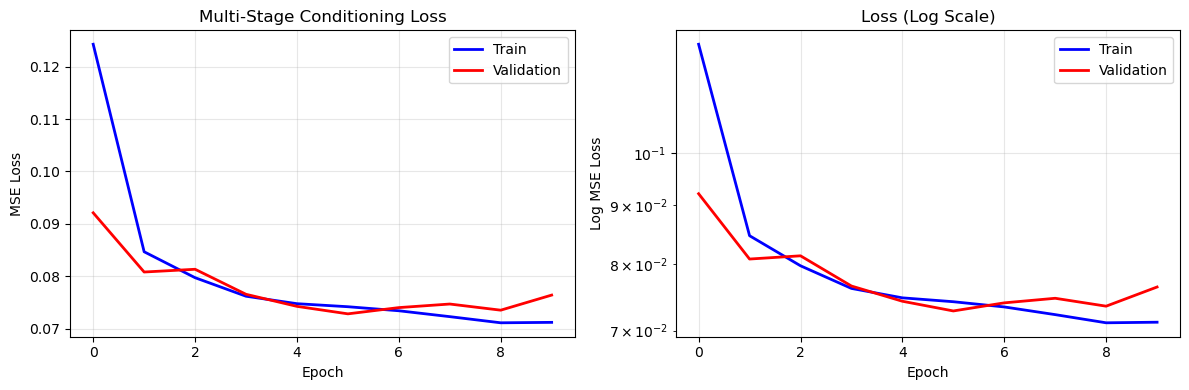


TOTAL TRAINING TIME: 16.0 minutes


In [17]:
if __name__ == "__main__":

    
    # Parameters
    ZERO_THRESHOLD = 0.2  # kept for compatibility; no residue clipping is applied
    UPPER_LIMIT_MULTIPLIER = 20.0  # Multiply p99 by this for upper limit
    NORM_CLIP_RANGE = (-100, 100)  # Diffusion-state clipping only; no residue normalization
    NUM_REALIZATIONS = 1  # Number of ensemble members to generate
    NUM_VISUALIZATION_SAMPLES = 5  # Number of samples to visualize
    
    MSE_WEIGHT = 1.0
    SWD_WEIGHT = 0.0
    NUM_PROJECTIONS = 32
    
    print(f"\nTraining Parameters:")
    print(f"  Zero threshold: {ZERO_THRESHOLD} mm/hr")
    print(f"  Upper limit: p99 × {UPPER_LIMIT_MULTIPLIER}")
    print(f"  Diffusion-state clipping: {NORM_CLIP_RANGE}")
    print(f"  Ensemble size: {NUM_REALIZATIONS}")
    print(f"  Visualization samples: {NUM_VISUALIZATION_SAMPLES}")
    print(f"  MSE weight: {MSE_WEIGHT}")
    print(f"  SWD weight: {SWD_WEIGHT}")
    print(f"  SWD projections: {NUM_PROJECTIONS}")

    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("\nGPU cache cleared")
    
    start_time = time.time()
    try:
        model, diffusion, processor, train_losses, val_losses, *_ = train_diffusion(
            zero_threshold=ZERO_THRESHOLD,
            upper_limit_multiplier=UPPER_LIMIT_MULTIPLIER,
            norm_clip_range=NORM_CLIP_RANGE,
            num_realizations=NUM_REALIZATIONS,
            num_visualization_samples=NUM_VISUALIZATION_SAMPLES,
            mse_weight=MSE_WEIGHT,
            swd_weight=SWD_WEIGHT,
            num_projections=NUM_PROJECTIONS
        )
        
        # Plot training progress
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, 'b-', linewidth=2, label='Train')
        plt.plot(val_losses, 'r-', linewidth=2, label='Validation')
        plt.title('Multi-Stage Conditioning Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.semilogy(train_losses, 'b-', linewidth=2, label='Train')
        plt.semilogy(val_losses, 'r-', linewidth=2, label='Validation')
        plt.title('Loss (Log Scale)')
        plt.xlabel('Epoch')
        plt.ylabel('Log MSE Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\nERROR: {e}")
        import traceback
        traceback.print_exc()
    
    total_time = time.time() - start_time
    
    print(f"\n" + "=" * 80)
    print(f"TOTAL TRAINING TIME: {total_time/60:.1f} minutes")
    print("=" * 80)